# Resampling Dataset Generation



# 00. Import 

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    balanced_accuracy_score, f1_score
)

from imblearn.over_sampling import RandomOverSampler, SMOTE, BorderlineSMOTE
from imblearn.combine import SMOTETomek

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

OUTPUT_REPORTS  = '../../../outputs/reports/'
OUTPUT_FIGURES  = '../../../outputs/figures/resampling_diagnostics/'
OUTPUT_DATASETS = '../../../outputs/datasets/resampling_experiments/'

import os
for path in [OUTPUT_REPORTS, OUTPUT_FIGURES, OUTPUT_DATASETS]:
    os.makedirs(path, exist_ok=True)

print('Libraries loaded.')

Libraries loaded.


# 01. load

In [18]:
# Fungsi ini di-reproduce dari notebook 05 agar notebook 06 bisa dijalankan standalone.
df = pd.read_csv('../../../data/processed/daily_eda_dataset.csv')

def build_engineered_features(df):
    df = df.copy()
    df['social_media_ratio']       = df['social_media_hours'] / (df['screen_time_hours'] + 1e-9)
    df['study_screen_balance']     = df['study_hours'] / (df['screen_time_hours'] + 1)
    df['academic_pressure_index']  = (df['assignment_load'] + df['deadline_pressure']) / 2
    df['recovery_index']           = (df['sleep_hours'] * df['mood_score']) / (df['fatigue_level'] + 1)
    df['digital_pressure_index']   = df['screen_time_hours'] + df['social_media_hours']
    df['emotional_pressure_index'] = df['fatigue_level'] + (10 - df['mood_score'])
    return df

df = build_engineered_features(df)

CORE_FEATURES = [
    'sleep_hours', 'physical_activity_minutes', 'study_hours',
    'screen_time_hours', 'assignment_load', 'deadline_pressure',
    'fatigue_level', 'mood_score'
]
ENGINEERED_NUMERIC = [
    'social_media_ratio', 'study_screen_balance', 'academic_pressure_index',
    'recovery_index', 'digital_pressure_index', 'emotional_pressure_index'
]

FLAGGED_ENGINEERED = ['emotional_pressure_index']  

BEST_FEATURES = CORE_FEATURES + [f for f in ENGINEERED_NUMERIC if f not in FLAGGED_ENGINEERED]

TARGET    = 'stress_level'
GROUP_COL = 'user_id'

print(f'Dataset shape   : {df.shape}')
print(f'Best features   : {len(BEST_FEATURES)} features')
print(f'Features        : {BEST_FEATURES}')

Dataset shape   : (26579, 27)
Best features   : 13 features
Features        : ['sleep_hours', 'physical_activity_minutes', 'study_hours', 'screen_time_hours', 'assignment_load', 'deadline_pressure', 'fatigue_level', 'mood_score', 'social_media_ratio', 'study_screen_balance', 'academic_pressure_index', 'recovery_index', 'digital_pressure_index']


# 02. Reproduce split

In [19]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(df, df[TARGET], groups=df[GROUP_COL]))

df_train = df.iloc[train_idx].copy().reset_index(drop=True)
df_test  = df.iloc[test_idx].copy().reset_index(drop=True)

X_train_raw = df_train[BEST_FEATURES].values
y_train_raw = df_train[TARGET].values
X_test_raw  = df_test[BEST_FEATURES].values
y_test_raw  = df_test[TARGET].values

print(f'Train: {len(df_train):5d} rows | {df_train[GROUP_COL].nunique()} users')
print(f'Test : {len(df_test):5d} rows | {df_test[GROUP_COL].nunique()} users')
print()

train_dist = pd.Series(y_train_raw).value_counts()
print('Distribusi train set (sebelum resampling):')
for cls in ['Low', 'Medium', 'High']:
    n = train_dist.get(cls, 0)
    print(f'  {cls:8s}: {n:5d} ({n/len(df_train)*100:.1f}%)')

Train: 21256 rows | 240 users
Test :  5323 rows | 60 users

Distribusi train set (sebelum resampling):
  Low     :   627 (2.9%)
  Medium  : 18596 (87.5%)
  High    :  2033 (9.6%)


# 03. setup evaluasi

In [20]:
le = LabelEncoder()
le.fit(['Low', 'Medium', 'High'])

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled  = scaler.transform(X_test_raw)  

y_train_enc = le.transform(y_train_raw)
y_test_enc  = le.transform(y_test_raw)

def evaluate(y_true, y_pred, method_name, n_train_per_class):
    report = classification_report(
        y_true, y_pred,
        target_names=le.classes_,
        output_dict=True,
        zero_division=0
    )
    result = {
        'method'           : method_name,
        'n_train_Low'      : n_train_per_class.get('Low', 0),
        'n_train_Medium'   : n_train_per_class.get('Medium', 0),
        'n_train_High'     : n_train_per_class.get('High', 0),
        'accuracy'         : round(report['accuracy'], 4),
        'macro_f1'         : round(report['macro avg']['f1-score'], 4),
        'balanced_accuracy': round(balanced_accuracy_score(y_true, y_pred), 4),
        'recall_Low'       : round(report['Low']['recall'], 4),
        'recall_Medium'    : round(report['Medium']['recall'], 4),
        'recall_High'      : round(report['High']['recall'], 4),
        'precision_Low'    : round(report['Low']['precision'], 4),
        'precision_Medium' : round(report['Medium']['precision'], 4),
        'precision_High'   : round(report['High']['precision'], 4),
        'f1_Low'           : round(report['Low']['f1-score'], 4),
        'f1_Medium'        : round(report['Medium']['f1-score'], 4),
        'f1_High'          : round(report['High']['f1-score'], 4),
    }
    return result

all_results   = []
all_cms       = {}
all_datasets  = {}  

# 04. Eksperimen 1 : No resampling (Baseline)


In [21]:
clf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
clf.fit(X_train_scaled, y_train_enc)
y_pred = clf.predict(X_test_scaled)

n_per_class = pd.Series(y_train_raw).value_counts().to_dict()
result = evaluate(y_test_enc, y_pred, 'no_resampling', n_per_class)
all_results.append(result)
all_cms['no_resampling'] = confusion_matrix(y_test_enc, y_pred)

df_train_out = df_train[BEST_FEATURES + [TARGET]].copy()
df_train_out.to_csv(OUTPUT_DATASETS + 'train_no_resampling.csv', index=False)
df_test[BEST_FEATURES + [TARGET]].to_csv(OUTPUT_DATASETS + 'test_set.csv', index=False)

print('=== Eksperimen 1: No Resampling ===')
print(f'  Macro F1         : {result["macro_f1"]}')
print(f'  Balanced Accuracy: {result["balanced_accuracy"]}')
print(f'  Recall Low       : {result["recall_Low"]}')
print(f'  Recall High      : {result["recall_High"]}')
print()
print('Saved: train_no_resampling.csv, test_set.csv')

=== Eksperimen 1: No Resampling ===
  Macro F1         : 0.6365
  Balanced Accuracy: 0.5903
  Recall Low       : 0.1858
  Recall High      : 0.6127

Saved: train_no_resampling.csv, test_set.csv


# 05. Eksperimen 2 : Class Weight

In [22]:
clf_cw = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
clf_cw.fit(X_train_scaled, y_train_enc)
y_pred_cw = clf_cw.predict(X_test_scaled)

result_cw = evaluate(y_test_enc, y_pred_cw, 'class_weight_balanced', n_per_class)
all_results.append(result_cw)
all_cms['class_weight_balanced'] = confusion_matrix(y_test_enc, y_pred_cw)

print('=== Eksperimen 2: Class Weight (balanced) ===')
print(f'  Macro F1         : {result_cw["macro_f1"]}')
print(f'  Balanced Accuracy: {result_cw["balanced_accuracy"]}')
print(f'  Recall Low       : {result_cw["recall_Low"]}')
print(f'  Recall High      : {result_cw["recall_High"]}')
# Tidak ada file CSV yang disimpan — class_weight tidak mengubah distribusi data

=== Eksperimen 2: Class Weight (balanced) ===
  Macro F1         : 0.6145
  Balanced Accuracy: 0.5671
  Recall Low       : 0.1327
  Recall High      : 0.5909


# 06. Eksperimen 3 : Random Over Sampler

In [23]:
# Target: seimbangkan ke jumlah kelas mayoritas (Medium)

ros = RandomOverSampler(random_state=42)
X_ros, y_ros = ros.fit_resample(X_train_scaled, y_train_enc)

n_ros = dict(zip(le.classes_, np.bincount(y_ros)))

clf_ros = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
clf_ros.fit(X_ros, y_ros)
y_pred_ros = clf_ros.predict(X_test_scaled)

result_ros = evaluate(y_test_enc, y_pred_ros, 'random_oversampler', n_ros)
all_results.append(result_ros)
all_cms['random_oversampler'] = confusion_matrix(y_test_enc, y_pred_ros)

# Simpan dataset hasil resampling (kembalikan ke original scale untuk CSV)
X_ros_orig = scaler.inverse_transform(X_ros)
df_ros = pd.DataFrame(X_ros_orig, columns=BEST_FEATURES)
df_ros[TARGET] = le.inverse_transform(y_ros)
df_ros.to_csv(OUTPUT_DATASETS + 'train_random_oversampler.csv', index=False)

print('=== Eksperimen 3: RandomOverSampler ===')
print(f'  Train size setelah resampling: {len(X_ros)}')
for cls in ['Low', 'Medium', 'High']:
    print(f'  {cls:8s}: {n_ros.get(cls, 0)}')
print(f'  Macro F1         : {result_ros["macro_f1"]}')
print(f'  Balanced Accuracy: {result_ros["balanced_accuracy"]}')
print(f'  Recall Low       : {result_ros["recall_Low"]}')
print(f'  Recall High      : {result_ros["recall_High"]}')
print('Saved: train_random_oversampler.csv')

=== Eksperimen 3: RandomOverSampler ===
  Train size setelah resampling: 55788
  Low     : 18596
  Medium  : 18596
  High    : 18596
  Macro F1         : 0.6828
  Balanced Accuracy: 0.6515
  Recall Low       : 0.3009
  Recall High      : 0.6909
Saved: train_random_oversampler.csv


# 07. Eksperimen 4 :SMOTE

In [24]:
# SMOTE

smote = SMOTE(random_state=42, k_neighbors=5)
X_sm, y_sm = smote.fit_resample(X_train_scaled, y_train_enc)

n_sm = dict(zip(le.classes_, np.bincount(y_sm)))

clf_sm = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

clf_sm.fit(X_sm, y_sm)

y_pred_sm = clf_sm.predict(X_test_scaled)

result_sm = evaluate(
    y_test_enc,
    y_pred_sm,
    'smote',
    n_sm
)

all_results.append(result_sm)
all_cms['smote'] = confusion_matrix(y_test_enc, y_pred_sm)

# simpan dataset hasil resampling
X_sm_orig = scaler.inverse_transform(X_sm)

df_sm = pd.DataFrame(X_sm_orig, columns=BEST_FEATURES)
df_sm[TARGET] = le.inverse_transform(y_sm)

df_sm.to_csv(
    OUTPUT_DATASETS + 'train_smote.csv',
    index=False
)

print('=== Eksperimen 4: SMOTE ===')
print(f'Train size : {len(X_sm)}')

for cls in ['Low', 'Medium', 'High']:
    print(f'{cls:8s}: {n_sm.get(cls, 0)}')

print(f'Macro F1          : {result_sm["macro_f1"]}')
print(f'Balanced Accuracy : {result_sm["balanced_accuracy"]}')
print(f'Recall Low        : {result_sm["recall_Low"]}')
print(f'Recall High       : {result_sm["recall_High"]}')

print('Saved: train_smote.csv')

=== Eksperimen 4: SMOTE ===
Train size : 55788
Low     : 18596
Medium  : 18596
High    : 18596
Macro F1          : 0.7082
Balanced Accuracy : 0.7193
Recall Low        : 0.4513
Recall High       : 0.7636
Saved: train_smote.csv


# 08. Eksperimen 5 : BorderlineSMOTE

In [25]:


bl_smote = BorderlineSMOTE(
    random_state=42,
    k_neighbors=5,
    kind='borderline-1'
)

X_bl, y_bl = bl_smote.fit_resample(
    X_train_scaled,
    y_train_enc
)

n_bl = dict(zip(le.classes_, np.bincount(y_bl)))

clf_bl = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

clf_bl.fit(X_bl, y_bl)

y_pred_bl = clf_bl.predict(X_test_scaled)

result_bl = evaluate(
    y_test_enc,
    y_pred_bl,
    'borderline_smote',
    n_bl
)

all_results.append(result_bl)

all_cms['borderline_smote'] = confusion_matrix(
    y_test_enc,
    y_pred_bl
)

# simpan dataset hasil resampling
X_bl_orig = scaler.inverse_transform(X_bl)

df_bl = pd.DataFrame(
    X_bl_orig,
    columns=BEST_FEATURES
)

df_bl[TARGET] = le.inverse_transform(y_bl)

df_bl.to_csv(
    OUTPUT_DATASETS + 'train_borderline_smote.csv',
    index=False
)

print('=== Eksperimen 5: BorderlineSMOTE ===')
print(f'Train size : {len(X_bl)}')

for cls in ['Low', 'Medium', 'High']:
    print(f'{cls:8s}: {n_bl.get(cls, 0)}')

print(f'Macro F1          : {result_bl["macro_f1"]}')
print(f'Balanced Accuracy : {result_bl["balanced_accuracy"]}')
print(f'Recall Low        : {result_bl["recall_Low"]}')
print(f'Recall High       : {result_bl["recall_High"]}')

print('Saved: train_borderline_smote.csv')

=== Eksperimen 5: BorderlineSMOTE ===
Train size : 55788
Low     : 18596
Medium  : 18596
High    : 18596
Macro F1          : 0.7025
Balanced Accuracy : 0.7136
Recall Low        : 0.4425
Recall High       : 0.7582
Saved: train_borderline_smote.csv


# 09. Eksperimen 6 : SMOTE - TOMEK

In [26]:
smote_tomek = SMOTETomek(random_state=42)

X_st, y_st = smote_tomek.fit_resample(
    X_train_scaled,
    y_train_enc
)

n_st = dict(zip(le.classes_, np.bincount(y_st)))

clf_st = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

clf_st.fit(X_st, y_st)

y_pred_st = clf_st.predict(X_test_scaled)

result_st = evaluate(
    y_test_enc,
    y_pred_st,
    'smote_tomek',
    n_st
)

all_results.append(result_st)

all_cms['smote_tomek'] = confusion_matrix(
    y_test_enc,
    y_pred_st
)

# simpan dataset hasil resampling
X_st_orig = scaler.inverse_transform(X_st)

df_st = pd.DataFrame(
    X_st_orig,
    columns=BEST_FEATURES
)

df_st[TARGET] = le.inverse_transform(y_st)

df_st.to_csv(
    OUTPUT_DATASETS + 'train_smote_tomek.csv',
    index=False
)

print('=== Eksperimen 6: SMOTE-Tomek ===')
print(f'Train size : {len(X_st)}')

for cls in ['Low', 'Medium', 'High']:
    print(f'{cls:8s}: {n_st.get(cls, 0)}')

print(f'Macro F1          : {result_st["macro_f1"]}')
print(f'Balanced Accuracy : {result_st["balanced_accuracy"]}')
print(f'Recall Low        : {result_st["recall_Low"]}')
print(f'Recall High       : {result_st["recall_High"]}')

print('Saved: train_smote_tomek.csv')

=== Eksperimen 6: SMOTE-Tomek ===
Train size : 55762
Low     : 18595
Medium  : 18583
High    : 18584
Macro F1          : 0.706
Balanced Accuracy : 0.7229
Recall Low        : 0.4602
Recall High       : 0.7673
Saved: train_smote_tomek.csv


# 10. Eksperimen 7 : Original + Engineered Full + SMOTE

In [27]:

SCENARIO_C = [
    'sleep_hours', 'study_hours', 'screen_time_hours', 'social_media_hours',
    'physical_activity_minutes', 'caffeine_intake_mg', 'mood_score',
    'fatigue_level', 'assignment_load', 'deadline_pressure',
    'social_interaction_score', 'financial_worry_score', 'health_condition_score',
    'social_media_ratio', 'study_screen_balance', 'academic_pressure_index',
    'recovery_index', 'digital_pressure_index', 'emotional_pressure_index'
]

X_train_c = df_train[SCENARIO_C].values
X_test_c  = df_test[SCENARIO_C].values

scaler_c = StandardScaler()
X_train_c_scaled = scaler_c.fit_transform(X_train_c)
X_test_c_scaled  = scaler_c.transform(X_test_c)

smote_c = SMOTE(random_state=42, k_neighbors=5)
X_c_sm, y_c_sm = smote_c.fit_resample(X_train_c_scaled, y_train_enc)

n_c_sm = dict(zip(le.classes_, np.bincount(y_c_sm)))

clf_c_sm = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
clf_c_sm.fit(X_c_sm, y_c_sm)
y_pred_c_sm = clf_c_sm.predict(X_test_c_scaled)

result_c_sm = evaluate(y_test_enc, y_pred_c_sm, 'smote_full_engineered', n_c_sm)
all_results.append(result_c_sm)
all_cms['smote_full_engineered'] = confusion_matrix(y_test_enc, y_pred_c_sm)

X_c_sm_orig = scaler_c.inverse_transform(X_c_sm)
df_c_sm = pd.DataFrame(X_c_sm_orig, columns=SCENARIO_C)
df_c_sm[TARGET] = le.inverse_transform(y_c_sm)
df_c_sm.to_csv(OUTPUT_DATASETS + 'train_smote_full_engineered.csv', index=False)

print('=== Eksperimen 7: SMOTE + Full Engineered Features (Scenario C) ===')
print(f'  Macro F1         : {result_c_sm["macro_f1"]}')
print(f'  Balanced Accuracy: {result_c_sm["balanced_accuracy"]}')
print(f'  Recall Low       : {result_c_sm["recall_Low"]}')
print(f'  Recall High      : {result_c_sm["recall_High"]}')
print('Saved: train_smote_full_engineered.csv')

=== Eksperimen 7: SMOTE + Full Engineered Features (Scenario C) ===
  Macro F1         : 0.7085
  Balanced Accuracy: 0.7078
  Recall Low       : 0.4159
  Recall High      : 0.7582
Saved: train_smote_full_engineered.csv


# 11. Metric Comparison semua eksperimen

In [28]:
results_df = pd.DataFrame(all_results)

cols_display = [
    'method', 'n_train_Low', 'n_train_Medium', 'n_train_High',
    'macro_f1', 'balanced_accuracy',
    'recall_Low', 'recall_Medium', 'recall_High',
    'precision_Low', 'precision_High'
]

print('=== Metric Comparison — Semua Eksperimen ===')
print(results_df[cols_display].to_string(index=False))
print()

results_df.to_csv(OUTPUT_REPORTS + 'resampling_metric_comparison.csv', index=False)
print('Saved: resampling_metric_comparison.csv')

=== Metric Comparison — Semua Eksperimen ===
               method  n_train_Low  n_train_Medium  n_train_High  macro_f1  balanced_accuracy  recall_Low  recall_Medium  recall_High  precision_Low  precision_High
        no_resampling          627           18596          2033    0.6365             0.5903      0.1858         0.9723       0.6127         0.5833          0.7472
class_weight_balanced          627           18596          2033    0.6145             0.5671      0.1327         0.9777       0.5909         0.6000          0.7757
   random_oversampler        18596           18596         18596    0.6828             0.6515      0.3009         0.9627       0.6909         0.5397          0.7238
                smote        18596           18596         18596    0.7082             0.7193      0.4513         0.9429       0.7636         0.4722          0.6677
     borderline_smote        18596           18596         18596    0.7025             0.7136      0.4425         0.9401       0.7

# 12. Visualisasi Perbandingan Metric

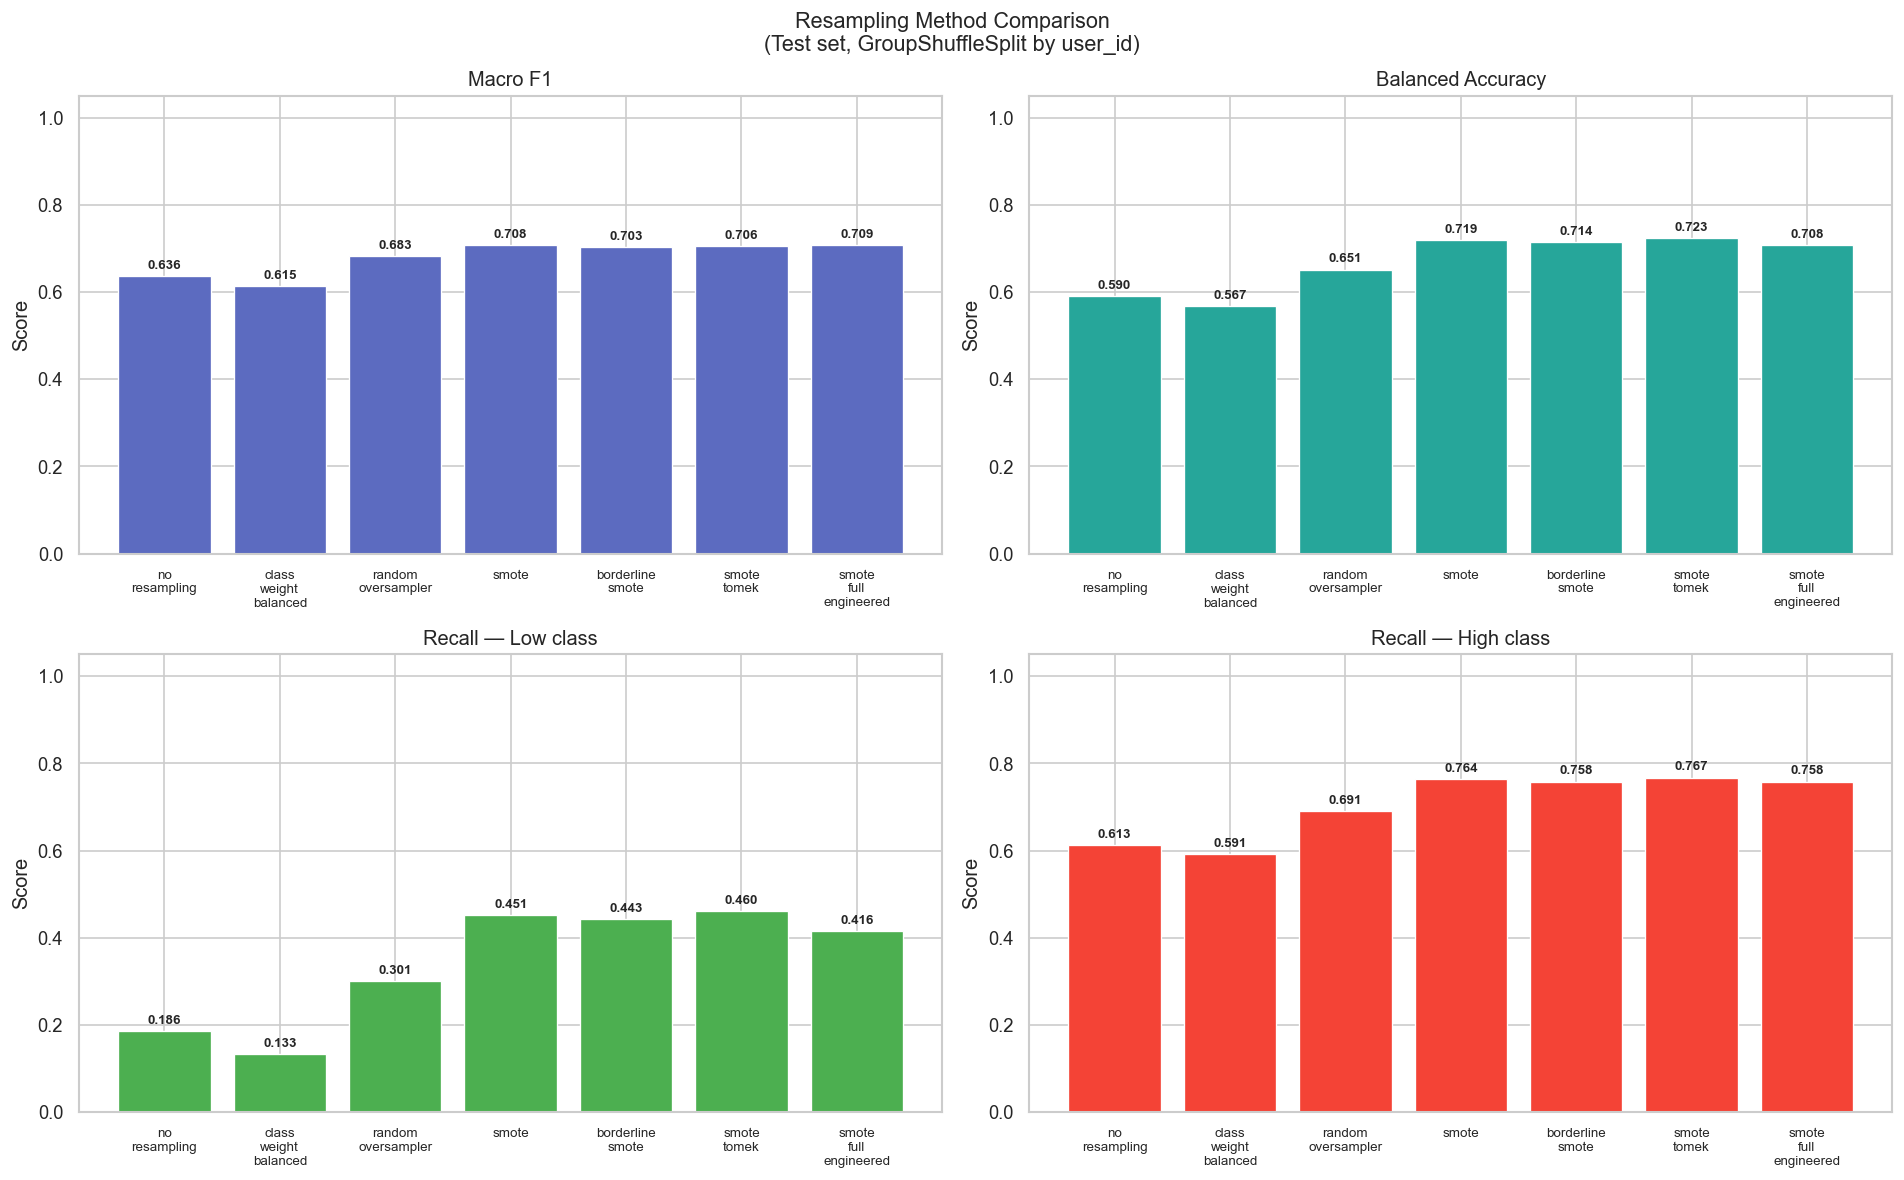

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Resampling Method Comparison\n(Test set, GroupShuffleSplit by user_id)', fontsize=13)

method_labels = results_df['method'].str.replace('_', '\n')

plots = [
    ('macro_f1',          'Macro F1',           '#5C6BC0'),
    ('balanced_accuracy', 'Balanced Accuracy',   '#26A69A'),
    ('recall_Low',        'Recall — Low class',  '#4CAF50'),
    ('recall_High',       'Recall — High class', '#F44336'),
]

for ax, (metric, title, color) in zip(axes.flatten(), plots):
    bars = ax.bar(method_labels, results_df[metric], color=color, edgecolor='white', linewidth=0.8)
    ax.set_title(title)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Score')
    ax.tick_params(axis='x', labelsize=8)
    for bar, val in zip(bars, results_df[metric]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f'{val:.3f}',
            ha='center', va='bottom', fontsize=8, fontweight='bold'
        )

plt.tight_layout()
plt.savefig(OUTPUT_FIGURES + '06_resampling_metric_comparison.png', bbox_inches='tight')
plt.show()

# 13. Confusion Matrix semua metode dalam satu figure

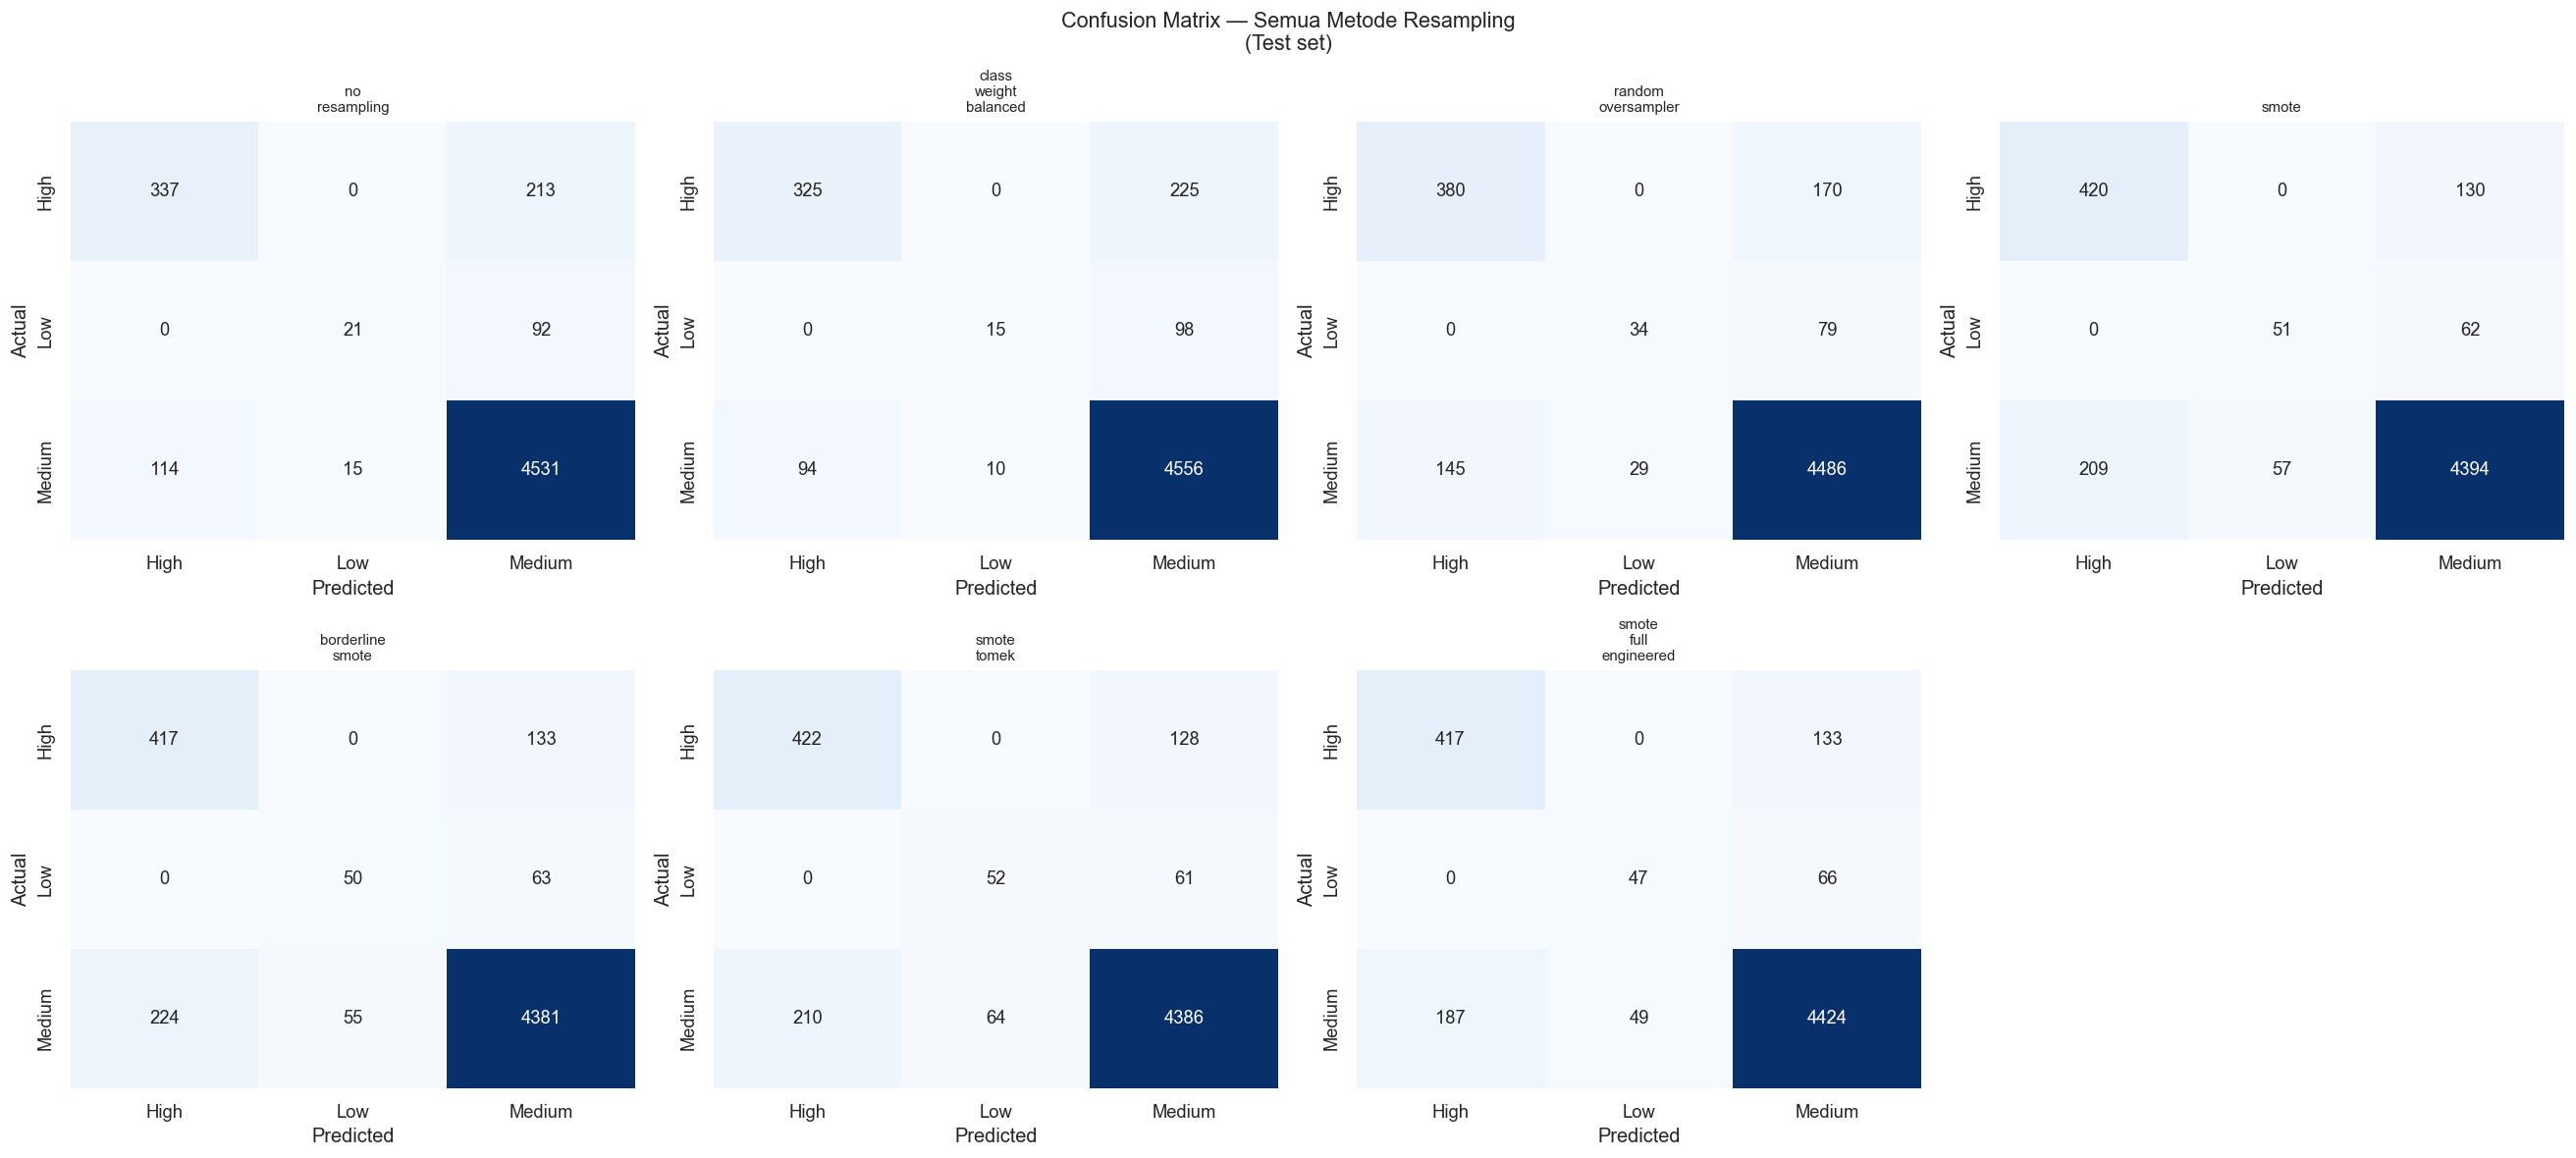

In [30]:
n_methods = len(all_cms)
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
fig.suptitle('Confusion Matrix — Semua Metode Resampling\n(Test set)', fontsize=13)

axes_flat = axes.flatten()

for i, (method_name, cm) in enumerate(all_cms.items()):
    ax = axes_flat[i]
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=le.classes_, yticklabels=le.classes_,
        ax=ax, cbar=False
    )
    ax.set_title(method_name.replace('_', '\n'), fontsize=9)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

# Hide unused subplot jika jumlah eksperimen < 8
for j in range(len(all_cms), len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_FIGURES + '07_confusion_matrix_all_methods.png', bbox_inches='tight')
plt.show()

# 14. Resampling Recommendation Status

In [31]:
def assign_status(row, low_mixing=0.782, high_mixing=0.489): #lihat notebook 05 section 09
    method  = row['method']
    macro   = row['macro_f1']
    rec_low = row['recall_Low']
    bal_acc = row['balanced_accuracy']

    baseline_macro   = results_df.loc[results_df['method'] == 'no_resampling', 'macro_f1'].values[0]
    baseline_rec_low = results_df.loc[results_df['method'] == 'no_resampling', 'recall_Low'].values[0]

    improved_macro   = macro > baseline_macro
    improved_rec_low = rec_low > baseline_rec_low

    if method == 'no_resampling':
        return 'baseline'

    if method == 'class_weight_balanced':
        return 'comparison_only'

    if method in ('smote', 'smote_full_engineered') and low_mixing > 0.60:
        if improved_macro and rec_low > 0.40:
            return 'experimental'
        return 'not_recommended'

    if improved_macro and improved_rec_low and bal_acc > 0.55:
        return 'recommended'
    elif improved_macro or improved_rec_low:
        return 'experimental'
    else:
        return 'not_recommended'

results_df['status'] = results_df.apply(assign_status, axis=1)

print('=== Resampling Recommendation Status ===')
for _, row in results_df[['method', 'macro_f1', 'recall_Low', 'balanced_accuracy', 'status']].iterrows():
    print(f'  {row["method"]:35s} | macro_f1={row["macro_f1"]:.4f} | recall_Low={row["recall_Low"]:.4f} | {row["status"]}')

results_df.to_csv(OUTPUT_REPORTS + 'resampling_metric_comparison.csv', index=False)
print()
print('Updated: resampling_metric_comparison.csv (dengan kolom status)')

=== Resampling Recommendation Status ===
  no_resampling                       | macro_f1=0.6365 | recall_Low=0.1858 | baseline
  class_weight_balanced               | macro_f1=0.6145 | recall_Low=0.1327 | comparison_only
  random_oversampler                  | macro_f1=0.6828 | recall_Low=0.3009 | recommended
  smote                               | macro_f1=0.7082 | recall_Low=0.4513 | experimental
  borderline_smote                    | macro_f1=0.7025 | recall_Low=0.4425 | recommended
  smote_tomek                         | macro_f1=0.7060 | recall_Low=0.4602 | recommended
  smote_full_engineered               | macro_f1=0.7085 | recall_Low=0.4159 | experimental

Updated: resampling_metric_comparison.csv (dengan kolom status)


# 15. Summary Output


In [32]:
print('=== Summary Output Notebook 06 ===')
print()

print('Datasets (outputs/datasets/resampling_experiments/):')

datasets_info = [
    ('train_no_resampling.csv',         'Baseline - no resampling'),
    ('test_set.csv',                    'Test set - jangan disentuh untuk resampling'),
    ('train_random_oversampler.csv',    'RandomOverSampler'),
    ('train_smote.csv',                 'SMOTE - experimental (Low overlap 78.2%)'),
    ('train_borderline_smote.csv',      'BorderlineSMOTE - candidate'),
    ('train_smote_tomek.csv',           'SMOTE-Tomek - candidate kuat'),
    ('train_smote_full_engineered.csv', 'SMOTE + full engineered - pembanding Scenario C'),
]

for fname, desc in datasets_info:
    print(f'  {fname:45s} -> {desc}')

print()

print('Reports (outputs/reports/):')
print('  resampling_metric_comparison.csv  -> metric + status semua metode')

print()

print('Figures (outputs/figures/resampling_diagnostics/):')
print('  06_resampling_metric_comparison.png')
print('  07_confusion_matrix_all_methods.png')

print()

print('Next step: 07_resampling_changelog_and_handoff.ipynb')
print('  -> Gunakan resampling_metric_comparison.csv sebagai input utama')
print('  -> Dokumentasikan status, alasan, risiko per dataset')
print('  -> Hasilkan resampling_changelog.md untuk handoff ke Tim AI Engineer')

=== Summary Output Notebook 06 ===

Datasets (outputs/datasets/resampling_experiments/):
  train_no_resampling.csv                       -> Baseline - no resampling
  test_set.csv                                  -> Test set - jangan disentuh untuk resampling
  train_random_oversampler.csv                  -> RandomOverSampler
  train_smote.csv                               -> SMOTE - experimental (Low overlap 78.2%)
  train_borderline_smote.csv                    -> BorderlineSMOTE - candidate
  train_smote_tomek.csv                         -> SMOTE-Tomek - candidate kuat
  train_smote_full_engineered.csv               -> SMOTE + full engineered - pembanding Scenario C

Reports (outputs/reports/):
  resampling_metric_comparison.csv  -> metric + status semua metode

Figures (outputs/figures/resampling_diagnostics/):
  06_resampling_metric_comparison.png
  07_confusion_matrix_all_methods.png

Next step: 07_resampling_changelog_and_handoff.ipynb
  -> Gunakan resampling_metric_comparison.

## Insight 

* Seluruh eksperimen dijalankan dengan konfigurasi yang konsisten. Semua metode menggunakan Scenario D sebagai feature set utama dan split `GroupShuffleSplit` yang sama (`random_state=42`) seperti pada notebook 05. Test set juga tetap dijaga dan tidak ikut di-resampling pada seluruh eksperimen.

* Baseline tanpa resampling digunakan sebagai acuan utama evaluasi. Kehadiran baseline penting untuk memastikan apakah suatu metode benar-benar meningkatkan performa model atau justru memperburuk pemisahan antar kelas.

* Pendekatan class weight tidak menghasilkan dataset baru karena hanya mengubah bobot loss saat training tanpa memodifikasi distribusi data. Meskipun demikian, performanya tetap dicatat sebagai pembanding metode non-oversampling.

* RandomOverSampler menyeimbangkan distribusi kelas dengan menduplikasi sample minoritas tanpa membuat data sintetis baru. Pendekatan ini relatif aman dari risiko noise akibat interpolasi, meskipun tidak menambah variasi data.

* SMOTE standar tetap diuji sebagai eksperimen, tetapi memiliki risiko tinggi karena overlap kelas Low sangat besar. Synthetic sample yang dihasilkan berpotensi berada di area yang sudah berdekatan dengan kelas Medium sehingga dapat memperburuk ambiguity antar kelas.

* BorderlineSMOTE lebih sesuai untuk kondisi overlap tinggi karena hanya melakukan oversampling pada sample yang berada di sekitar boundary antar kelas, bukan pada seluruh sample minoritas secara merata.

* SMOTE-Tomek mengombinasikan proses oversampling dan cleaning. Setelah synthetic sample dibuat, Tomek links digunakan untuk menghapus sample yang terlalu dekat antar kelas sehingga area transisi menjadi lebih bersih.

* Eksperimen menggunakan SMOTE dengan seluruh engineered feature (Scenario C) dilakukan sebagai pembanding untuk melihat dampak fitur tambahan yang tidak lolos seleksi. Pendekatan ini membantu mengevaluasi apakah fitur redundan justru menambah noise pada proses resampling.

* Status rekomendasi setiap metode ditentukan secara programatik berdasarkan perbandingan terhadap baseline, terutama pada peningkatan macro F1, recall kelas Low, dan balanced accuracy. Metode yang tidak memenuhi kriteria tersebut diberi status `experimental` atau `not_recommended`.


## Conclusion

* Seluruh eksperimen resampling berhasil dijalankan dalam kondisi yang konsisten dan terkontrol. Semua metode menggunakan split yang sama, feature set yang sama, serta test set yang tetap dijaga tanpa modifikasi sehingga hasil evaluasi dapat dibandingkan secara fair.

* Setiap metode menghasilkan file dataset terpisah pada direktori `outputs/datasets/resampling_experiments/`, kecuali pendekatan `class_weight` karena metode ini tidak mengubah distribusi data asli.

* Status rekomendasi seluruh eksperimen telah disimpan pada file `resampling_metric_comparison.csv`. File ini menjadi acuan utama pada notebook 07 untuk proses handoff dan dokumentasi akhir.

* SMOTE standar dan SMOTE dengan full engineered feature diperkirakan memiliki risiko performa yang kurang stabil akibat tingginya overlap pada kelas Low. Oleh karena itu, kedua metode tersebut lebih berpotensi masuk kategori `experimental` atau `not_recommended`.

* BorderlineSMOTE dan SMOTE-Tomek menjadi kandidat yang paling menjanjikan untuk status `recommended`, terutama jika mampu meningkatkan macro F1, recall kelas Low, dan balanced accuracy dibandingkan baseline.


## Recomendation

* `train_smote.csv` tidak disarankan sebagai dataset training utama karena risiko synthetic noise cukup tinggi pada kondisi overlap kelas yang besar.

* `train_smote_tomek.csv` dan `train_borderline_smote.csv` lebih layak diprioritaskan jika status akhirnya `recommended`, karena keduanya lebih defensif terhadap overlap antar kelas.

* `train_random_oversampler.csv` masih dapat digunakan sebagai alternatif konservatif, terutama jika ingin menghindari synthetic sample, meskipun metode ini hanya melakukan duplikasi data minoritas.

* `test_set.csv` harus tetap dijaga dalam distribusi aslinya dan tidak boleh di-resampling maupun dimodifikasi selama proses modelling.

* Eksperimen SMOTE dengan full engineered feature (Scenario C) sebaiknya digunakan sebagai pembanding saja, bukan sebagai kandidat utama dataset training.

* File `resampling_metric_comparison.csv` perlu dibaca bersama changelog agar interpretasi hasil dan status rekomendasi setiap metode tetap memiliki konteks metodologis yang jelas.
